# Lysosome Masking for Hannah Bailey

## Load sample information

In [71]:
import pandas as pd

samplesheet = pd.read_csv("/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/hb_samplesheet.csv")
samplesheet

,filename,Treatment,ch0,ch1,ch2,ch3
0,20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_...,Nigericin,DAPI,GFAP,LAMP1,pRAB10
1,20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_Unt...,Untreated,DAPI,GFAP,LAMP1,pRAB10
2,20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_V1_...,Vacuolin-1,DAPI,GFAP,LAMP1,pRAB10
3,20250311_647pR10_488GFAP_561Lamp1_Apilimod_rep...,Apilimod,pRAB10,LAMP1,GFAP,DAPI
4,20250311_647pR10_488GFAP_561Lamp1_Apilimod_rep...,Apilimod,pRAB10,LAMP1,GFAP,DAPI
5,20250311_647pR10_488GFAP_561Lamp1_CQ_200uM2h_r...,Chloroquine,pRAB10,LAMP1,GFAP,DAPI
6,20250311_647pR10_488GFAP_561Lamp1_CQ_200uM2h_r...,Chloroquine,pRAB10,LAMP1,GFAP,DAPI
7,20250311_647pR10_488GFAP_561Lamp1_Mon_Rep1_003...,Monensin,pRAB10,LAMP1,GFAP,DAPI
8,20250311_647pR10_488GFAP_561Lamp1_Mon_Rep1_008...,Monensin,pRAB10,LAMP1,GFAP,DAPI
9,20250311_647pR10_488GFAP_561Lamp1_Mon_Rep1_012...,Monensin,pRAB10,LAMP1,GFAP,DAPI


Make a dict of the stain colors for automated image generation\
Make a dict to tie segmentations to stain info

## Load images

In [72]:
from pathlib import Path

img_dir = Path("/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages")
print(img_dir)

imgs = list(sorted(img_dir.glob('*.tif')))
print(imgs)

img = imgs[0]

/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages
[PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_002_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_Unt010_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_V1_006_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/20250311_647pR10_488GFAP_561Lamp1_Apilimod_rep1_022_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/20250311_647pR10_488GFAP_561Lamp1_Apilimod_rep1_023_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/20250311_647pR10_488GFAP_561Lamp1_CQ_200uM2h_rep1_010_MIP

Some of the images that Hannah sent have different channel orders - consider working with the metadata to automate this, otherwise just hardcode for now. \
These are basic tiffs, metadata does NOT include channel information... looks like hannah has most of this in the filenames though? Could use that or have her fill out a dataframe (tedious but accurate?) that could just be loaded in

In [73]:
import tifffile 
import os

img_1 = tifffile.imread(img)

print(img_1)
print(img_1.shape)

print(os.path.basename(img))

[[[ 109  107  110 ...  107  106  107]
  [ 107  108  108 ...  111  109  106]
  [ 107  107  106 ...  108  105  105]
  ...
  [ 110  109  109 ...  103  106  106]
  [ 106  106  104 ...  104  105  108]
  [ 104  105  107 ...  105  104  105]]

 [[ 160  143  142 ... 1429 1599 1763]
  [ 150  138  160 ... 1501 1640 1813]
  [ 153  157  160 ... 1607 1705 1799]
  ...
  [ 116  114  113 ...  303  377  440]
  [ 110  116  113 ...  236  297  372]
  [ 114  120  114 ...  200  216  263]]

 [[ 108  107  110 ...  109  110  117]
  [ 104  104  107 ...  114  115  111]
  [ 106  109  111 ...  112  107  106]
  ...
  [ 109  107  103 ...  105  105  109]
  [ 103  108  104 ...  109  108  108]
  [ 105  103  107 ...  105  110  106]]

 [[ 117  117  116 ...  110  116  116]
  [ 119  112  122 ...  113  117  119]
  [ 123  110  114 ...  112  114  117]
  ...
  [ 109  112  106 ...  104  112  106]
  [ 104  104  103 ...  107  107  106]
  [ 105  104  105 ...  105  106  113]]]
(4, 1200, 1200)
20240729_WT_ACs_pR10_647_Lamp1_568_GFAP4

## Preview an image

In [74]:
import napari

viewer = napari.Viewer()

viewer.add_image(img_1[0], 
                 name='DAPI',
                 blending="additive",
                 colormap="blue"
                 )

viewer.add_image(img_1[1], 
                 name='GFAP',
                 blending="additive",
                 colormap="green"
                 )

viewer.add_image(img_1[2], 
                 name='LAMP1',
                 blending="additive",
                 colormap="red")

viewer.add_image(img_1[3], 
                 name='pRAB10',
                 blending="additive",
                 colormap="magenta")

<Image layer 'pRAB10' at 0x3861c6990>

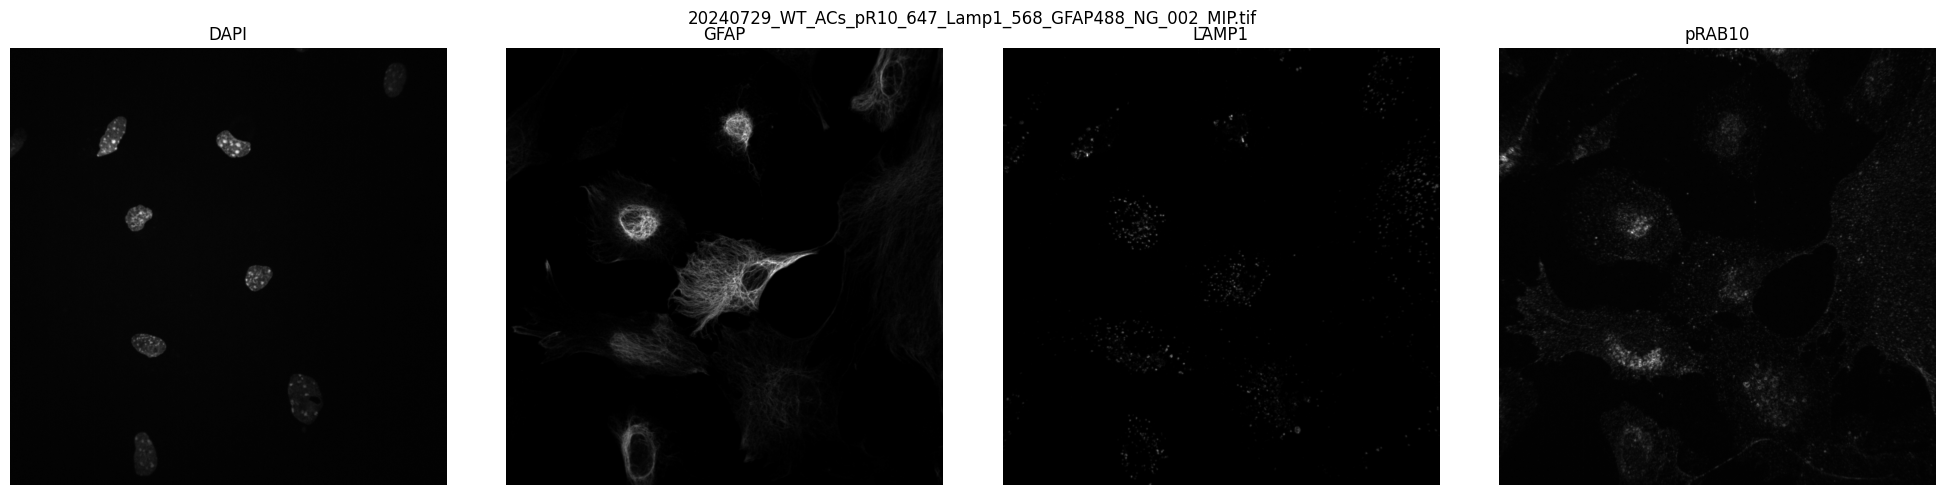

In [75]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(os.path.basename(img))

axs[0].imshow(img_1[0], cmap='gray') 
axs[0].set_title("DAPI")
axs[0].axis("off")

axs[1].imshow(img_1[1], cmap = "gray")
axs[1].set_title("GFAP")
axs[1].axis("off")

axs[2].imshow(img_1[2], cmap='gray')
axs[2].set_title("LAMP1")
axs[2].axis("off")

axs[3].imshow(img_1[3], cmap='gray')
axs[3].set_title("pRAB10")
axs[3].axis("off")

plt.tight_layout()
plt.show()

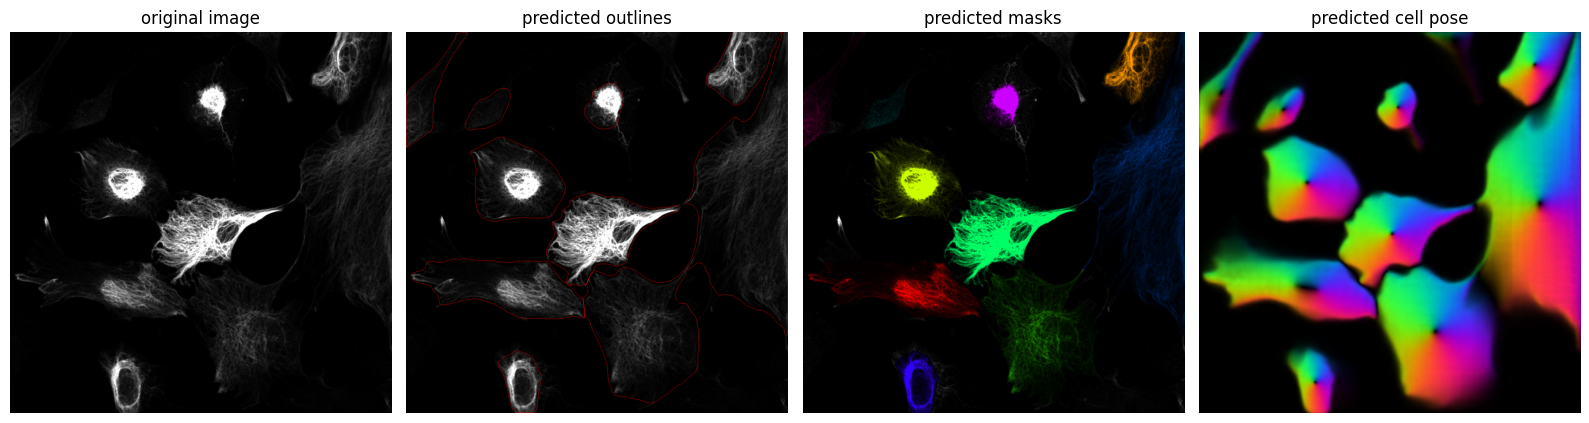

In [76]:
from cellpose import models, core, io, plot

flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

#io.logger_setup() # run this to get printing of progress

model = models.CellposeModel(gpu=True)

cellpose_cell_masks, flows, styles = model.eval(img_1[:2],
                                           batch_size=32, 
                                           diameter=120, 
                                           flow_threshold=flow_threshold, 
                                           cellprob_threshold=cellprob_threshold,
                                           normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(16,10))
plot.show_segmentation(fig, img_1[:2], cellpose_cell_masks, flows[0])
plt.tight_layout()
plt.show()

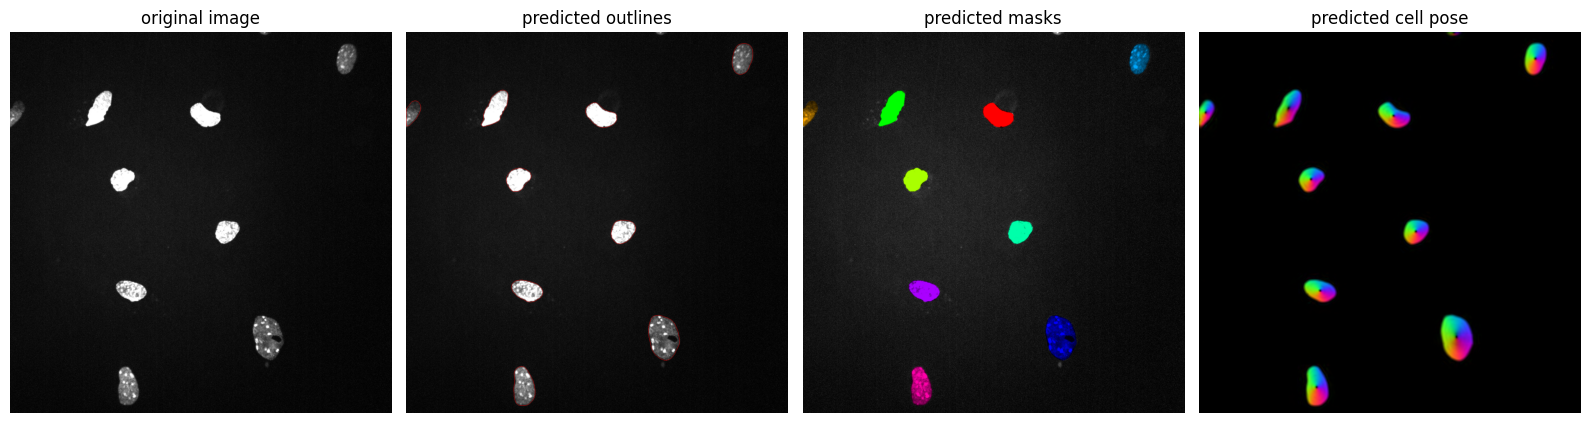

In [77]:
from cellpose import models, core, io, plot

flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

#io.logger_setup() # run this to get printing of progress

model = models.CellposeModel(gpu=True)

cellpose_nuc_masks, flows, styles = model.eval(img_1[0],
                                           batch_size=32, 
                                           diameter=120, 
                                           flow_threshold=flow_threshold, 
                                           cellprob_threshold=cellprob_threshold,
                                           normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(16,10))
plot.show_segmentation(fig, img_1[0], cellpose_nuc_masks, flows[0])
plt.tight_layout()
plt.show()

In [78]:
import napari

viewer = napari.Viewer()

viewer.add_image(img_1[0], 
                 name='DAPI',
                 blending="additive",
                 colormap="blue"
                 )

viewer.add_image(img_1[1], 
                 name='GFAP',
                 blending="additive",
                 colormap="green"
                 )

viewer.add_image(img_1[2], 
                 name='LAMP1',
                 blending="additive",
                 colormap="red")

viewer.add_image(img_1[3], 
                 name='pRAB10',
                 blending="additive",
                 colormap="magenta")

viewer.add_labels(cellpose_nuc_masks,
                  name = "Nucleus mask")

viewer.add_labels(cellpose_cell_masks,
                  name = "Cell mask")

<Labels layer 'Cell mask' at 0x38c85c190>

1. Make an ID for each cell region
2. Within each region run segmentation for: LAMP1 and pRAB10
3. Extract features tied to each cell

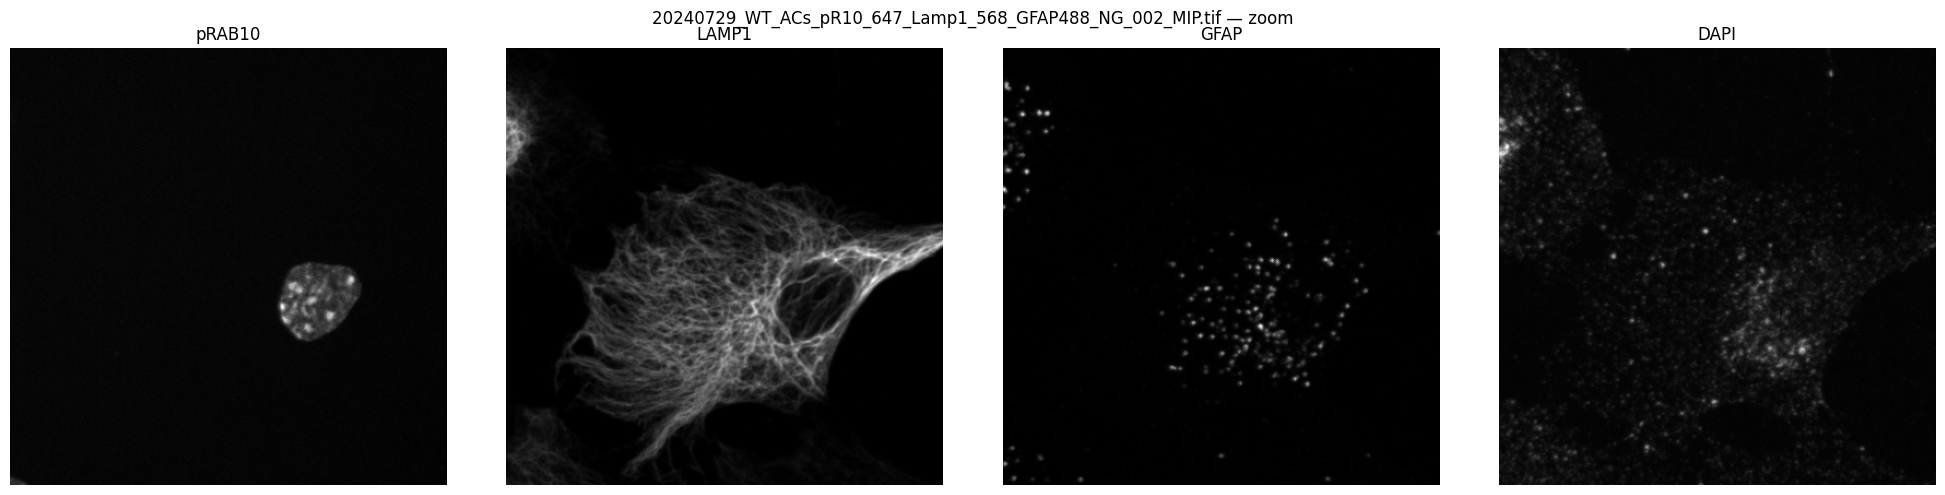

In [79]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f"{os.path.basename(img)} — zoom")

axs[0].imshow(img_1[0, 400:800, 400:800], cmap='gray') 
axs[0].set_title("pRAB10")
axs[0].axis("off")

axs[1].imshow(img_1[1, 400:800, 400:800], cmap = "gray")
axs[1].set_title("LAMP1")
axs[1].axis("off")

axs[2].imshow(img_1[2, 400:800, 400:800], cmap='gray')
axs[2].set_title("GFAP")
axs[2].axis("off")

axs[3].imshow(img_1[3, 400:800, 400:800], cmap='gray')
axs[3].set_title("DAPI")
axs[3].axis("off")

plt.tight_layout()
plt.show()

### ID lysosomes from a single image

In [80]:
from scipy.ndimage import gaussian_laplace
from skimage import filters, morphology
from scipy import ndimage as ndi
import numpy as np
from scipy.stats import norm

# Paramaters - same as ACIS standard
intensity_scaling_param = [3, 19]
min_lysosome_area = 5
blur_sigma = 1
log_sigma_1, log_cutoff_1 = 2.5, 0.07
log_sigma_2, log_cutoff_2 = 2.5, 0.07
log_sigma_3, log_cutoff_3 = 1, 0.01
vesselness_sigma = [1]
vesselness_cutoff = 0.15

lys_ch = img_1[2].copy().astype(float)

# Normalize image
#image_norm = (lys_ch - np.min(lys_ch)) / (np.max(lys_ch) - np.min(lys_ch))

# Normalize to normal distribution
m, s = norm.fit(lys_ch.flatten())
stretch_min = max(m - intensity_scaling_param[0] * s, lys_ch.min())
stretch_max = min(m + intensity_scaling_param[1] * s, lys_ch.max())
lys_ch_n = np.clip(lys_ch, stretch_min, stretch_max)
image_norm = (lys_ch_n - stretch_min) / (stretch_max - stretch_min)

# Blur image
blurred = filters.gaussian(image_norm, sigma=blur_sigma)

# Identify blobs
log_1 = -1 * (log_sigma_1**2) * gaussian_laplace(blurred, sigma=log_sigma_1)
log_2 = -1 * (log_sigma_2**2) * gaussian_laplace(blurred, sigma=log_sigma_2)
log_3 = -1 * (log_sigma_3**2) * gaussian_laplace(blurred, sigma=log_sigma_3)

log_1_mask = log_1 > log_cutoff_1
log_2_mask = log_2 > log_cutoff_2
log_3_mask = log_3 > log_cutoff_3

log_mask = np.logical_or(log_1_mask, log_2_mask)
log_mask = np.logical_or(log_mask, log_3_mask)

# Identify vessels
vesselness = filters.frangi(blurred, sigmas=vesselness_sigma, black_ridges=False) > vesselness_cutoff
combined = np.logical_or(log_mask, vesselness)

filled = ndi.binary_fill_holes(combined)
lysosome_mask = morphology.remove_small_objects(filled, min_size=min_lysosome_area)

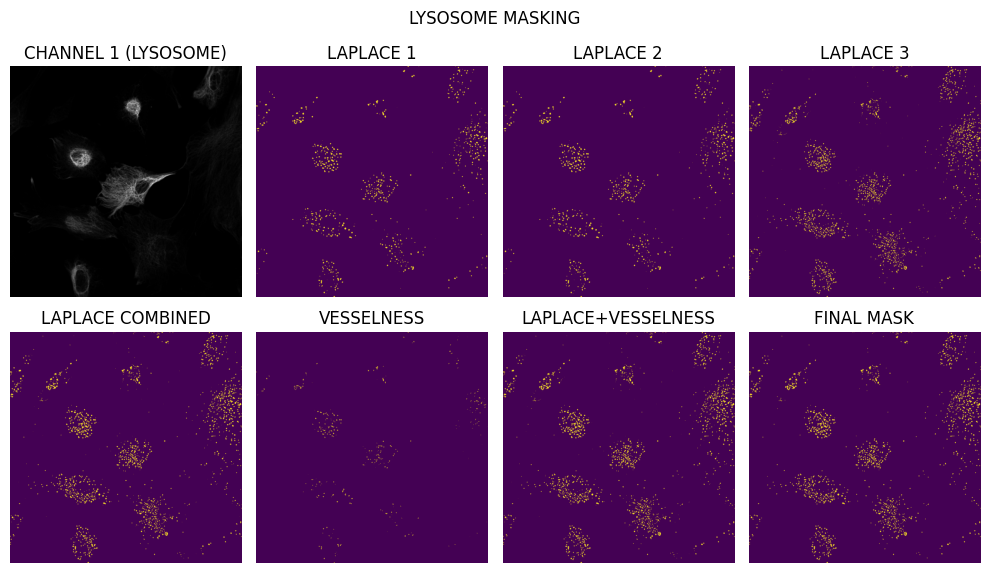

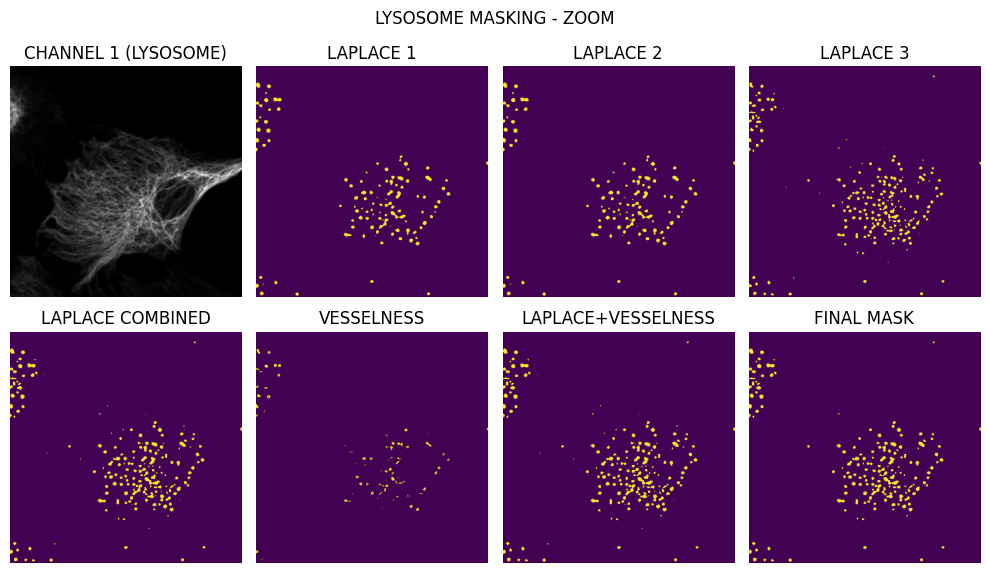

In [81]:
fig, axs = plt.subplots(2, 4, figsize=(10, 6))
fig.suptitle("LYSOSOME MASKING")

axs[0,0].imshow(img_1[1], cmap='gray')
axs[0,0].set_title("CHANNEL 1 (LYSOSOME)")
axs[0,0].axis("off")

axs[0,1].imshow(log_1_mask)
axs[0,1].set_title("LAPLACE 1")
axs[0,1].axis("off")

axs[0,2].imshow(log_2_mask)
axs[0,2].set_title("LAPLACE 2")
axs[0,2].axis("off")

axs[0,3].imshow(log_3_mask)
axs[0,3].set_title("LAPLACE 3")
axs[0,3].axis("off")

axs[1,0].imshow(log_mask)
axs[1,0].set_title("LAPLACE COMBINED")
axs[1,0].axis("off")

axs[1,1].imshow(vesselness)
axs[1,1].set_title("VESSELNESS")
axs[1,1].axis("off")

axs[1,2].imshow(combined)
axs[1,2].set_title("LAPLACE+VESSELNESS")
axs[1,2].axis("off")

axs[1,3].imshow(lysosome_mask)
axs[1,3].set_title("FINAL MASK")
axs[1,3].axis("off")

#plt.savefig("lysosome_mask_processing.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 4, figsize=(10, 6))
fig.suptitle("LYSOSOME MASKING - ZOOM")

axs[0,0].imshow(img_1[1, 400:800, 400:800], cmap='gray')
axs[0,0].set_title("CHANNEL 1 (LYSOSOME)")
axs[0,0].axis("off")

axs[0,1].imshow(log_1_mask[400:800, 400:800])
axs[0,1].set_title("LAPLACE 1")
axs[0,1].axis("off")

axs[0,2].imshow(log_2_mask[400:800, 400:800])
axs[0,2].set_title("LAPLACE 2")
axs[0,2].axis("off")

axs[0,3].imshow(log_3_mask[400:800, 400:800])
axs[0,3].set_title("LAPLACE 3")
axs[0,3].axis("off")

axs[1,0].imshow(log_mask[400:800, 400:800])
axs[1,0].set_title("LAPLACE COMBINED")
axs[1,0].axis("off")

axs[1,1].imshow(vesselness[400:800, 400:800])
axs[1,1].set_title("VESSELNESS")
axs[1,1].axis("off")

axs[1,2].imshow(combined[400:800, 400:800])
axs[1,2].set_title("LAPLACE+VESSELNESS")
axs[1,2].axis("off")

axs[1,3].imshow(lysosome_mask[400:800, 400:800])
axs[1,3].set_title("FINAL MASK")
axs[1,3].axis("off")

#plt.savefig("lysosome_mask_processing.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [82]:
import napari

viewer = napari.Viewer()

viewer.add_image(img_1[0], 
                 name='DAPI',
                 blending="additive",
                 colormap="blue"
                 )

viewer.add_image(img_1[1], 
                 name='GFAP',
                 blending="additive",
                 colormap="green"
                 )

viewer.add_image(img_1[2], 
                 name='LAMP1',
                 blending="additive",
                 colormap="red")

viewer.add_image(img_1[3], 
                 name='pRAB10',
                 blending="additive",
                 colormap="magenta")

viewer.add_labels(cellpose_nuc_masks,
                  name = "Nucleus mask")

viewer.add_labels(cellpose_cell_masks,
                  name = "Cell mask")

viewer.add_labels(lysosome_mask, 
                 name='LYSOSOME MASK')

<Labels layer 'LYSOSOME MASK' at 0x398c51f90>

### ID pRAB10 from a single image

In [ ]:
from scipy.ndimage import gaussian_laplace
from skimage import filters, morphology
from scipy import ndimage as ndi
import numpy as np
from scipy.stats import norm

# Paramaters - same as ACIS standard
intensity_scaling_param = [3, 19]
min_prab10_area = 5
blur_sigma = 1
log_sigma_1, log_cutoff_1 = 3, 0.07
log_sigma_2, log_cutoff_2 = 2, 0.04
log_sigma_3, log_cutoff_3 = 1, 0.01
vesselness_sigma = [1]
vesselness_cutoff = 0.15

prab_ch = img_1[3].copy().astype(float)

# Normalize image
#image_norm = (prab_ch - np.min(prab_ch)) / (np.max(prab_ch) - np.min(prab_ch))

# Normalize to normal distribution
m, s = norm.fit(prab_ch.flatten())
stretch_min = max(m - intensity_scaling_param[0] * s, prab_ch.min())
stretch_max = min(m + intensity_scaling_param[1] * s, prab_ch.max())
prab_ch_n = np.clip(prab_ch, stretch_min, stretch_max)
image_norm = (prab_ch_n - stretch_min) / (stretch_max - stretch_min)

# Blur image
blurred = filters.gaussian(image_norm, sigma=blur_sigma)

# Identify blobs
log_1 = -1 * (log_sigma_1**2) * gaussian_laplace(blurred, sigma=log_sigma_1)
log_2 = -1 * (log_sigma_2**2) * gaussian_laplace(blurred, sigma=log_sigma_2)
log_3 = -1 * (log_sigma_3**2) * gaussian_laplace(blurred, sigma=log_sigma_3)

log_1_mask = log_1 > log_cutoff_1
log_2_mask = log_2 > log_cutoff_2
log_3_mask = log_3 > log_cutoff_3

log_mask = np.logical_or(log_1_mask, log_2_mask)
log_mask = np.logical_or(log_mask, log_3_mask)

# Identify vessels
vesselness = filters.frangi(blurred, sigmas=vesselness_sigma, black_ridges=False) > vesselness_cutoff
combined = np.logical_or(log_mask, vesselness)

## add a watershed?

filled = ndi.binary_fill_holes(combined)
prab10_mask = morphology.remove_small_objects(filled, min_size=min_prab10_area)

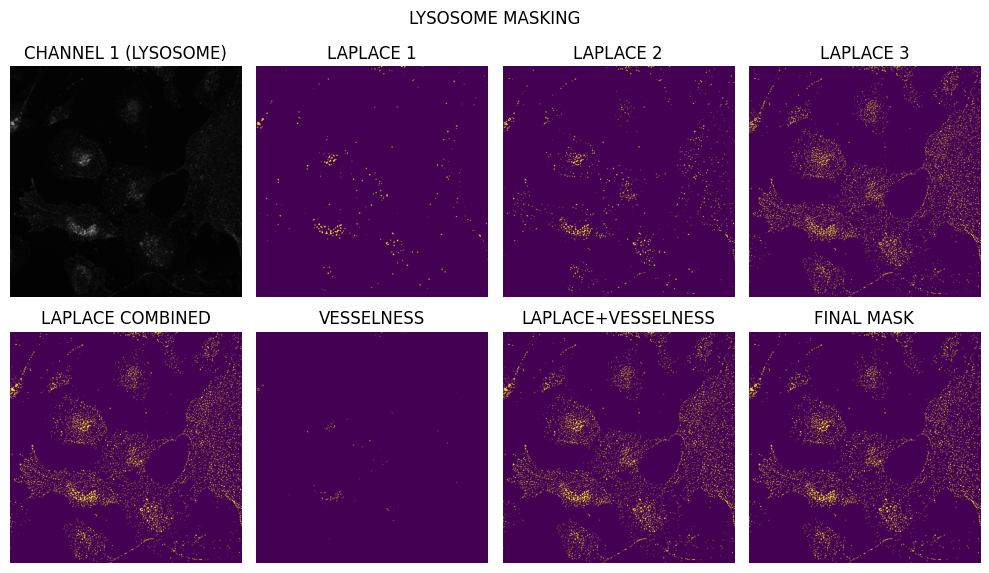

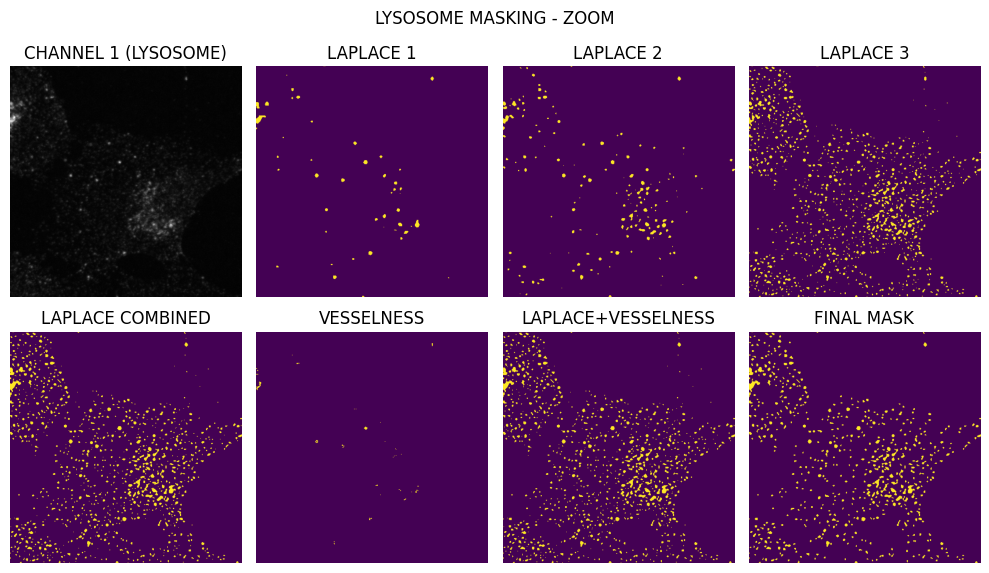

In [96]:
fig, axs = plt.subplots(2, 4, figsize=(10, 6))
fig.suptitle("LYSOSOME MASKING")

axs[0,0].imshow(img_1[3], cmap='gray')
axs[0,0].set_title("CHANNEL 1 (LYSOSOME)")
axs[0,0].axis("off")

axs[0,1].imshow(log_1_mask)
axs[0,1].set_title("LAPLACE 1")
axs[0,1].axis("off")

axs[0,2].imshow(log_2_mask)
axs[0,2].set_title("LAPLACE 2")
axs[0,2].axis("off")

axs[0,3].imshow(log_3_mask)
axs[0,3].set_title("LAPLACE 3")
axs[0,3].axis("off")

axs[1,0].imshow(log_mask)
axs[1,0].set_title("LAPLACE COMBINED")
axs[1,0].axis("off")

axs[1,1].imshow(vesselness)
axs[1,1].set_title("VESSELNESS")
axs[1,1].axis("off")

axs[1,2].imshow(combined)
axs[1,2].set_title("LAPLACE+VESSELNESS")
axs[1,2].axis("off")

axs[1,3].imshow(prab10_mask)
axs[1,3].set_title("FINAL MASK")
axs[1,3].axis("off")

#plt.savefig("lysosome_mask_processing.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 4, figsize=(10, 6))
fig.suptitle("LYSOSOME MASKING - ZOOM")

axs[0,0].imshow(img_1[3, 400:800, 400:800], cmap='gray')
axs[0,0].set_title("CHANNEL 1 (LYSOSOME)")
axs[0,0].axis("off")

axs[0,1].imshow(log_1_mask[400:800, 400:800])
axs[0,1].set_title("LAPLACE 1")
axs[0,1].axis("off")

axs[0,2].imshow(log_2_mask[400:800, 400:800])
axs[0,2].set_title("LAPLACE 2")
axs[0,2].axis("off")

axs[0,3].imshow(log_3_mask[400:800, 400:800])
axs[0,3].set_title("LAPLACE 3")
axs[0,3].axis("off")

axs[1,0].imshow(log_mask[400:800, 400:800])
axs[1,0].set_title("LAPLACE COMBINED")
axs[1,0].axis("off")

axs[1,1].imshow(vesselness[400:800, 400:800])
axs[1,1].set_title("VESSELNESS")
axs[1,1].axis("off")

axs[1,2].imshow(combined[400:800, 400:800])
axs[1,2].set_title("LAPLACE+VESSELNESS")
axs[1,2].axis("off")

axs[1,3].imshow(prab10_mask[400:800, 400:800])
axs[1,3].set_title("FINAL MASK")
axs[1,3].axis("off")

#plt.savefig("lysosome_mask_processing.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [97]:
import napari

viewer = napari.Viewer()

viewer.add_image(img_1[0], 
                 name='DAPI',
                 blending="additive",
                 colormap="blue"
                 )

viewer.add_image(img_1[1], 
                 name='GFAP',
                 blending="additive",
                 colormap="green"
                 )

viewer.add_image(img_1[2], 
                 name='LAMP1',
                 blending="additive",
                 colormap="red")

viewer.add_image(img_1[3], 
                 name='pRAB10',
                 blending="additive",
                 colormap="magenta")

viewer.add_labels(cellpose_nuc_masks,
                  name = "Nucleus mask")

viewer.add_labels(cellpose_cell_masks,
                  name = "Cell mask")

viewer.add_labels(lysosome_mask, 
                 name='LYSOSOME MASK')

viewer.add_labels(prab10_mask, 
                 name='PRAB10 MASK')

<Labels layer 'PRAB10 MASK' at 0x3af3c42d0>

In [55]:
import numpy as np
from scipy import ndimage as ndi
from skimage.measure import label, regionprops_table

cell_ids = np.unique(cellpose_cell_masks)
cell_ids = cell_ids[cell_ids != 0]
print(cell_ids)

lysosome_mask_labels = np.zeros_like(lysosome_mask, dtype=np.int32)
print(lysosome_mask_labels)

parent_cell_id = {}

current_label = 1

for cid in cell_ids:
    single_cell_mask = (cellpose_cell_masks == cid)

    obj_in_cell = lysosome_mask * single_cell_mask

    labeled_in_cell, n = ndi.label(obj_in_cell > 0)

    if n > 0:
        local_labels = np.unique(labeled_in_cell)
        local_labels = local_labels[local_labels != 0]
        
        for ll in local_labels:
            lysosome_mask_labels[(labeled_in_cell == ll)] = current_label
            parent_cell_id[current_label] = int(cid)
            current_label += 1

print("Number of sub-objects:", len(parent_cell_id))
print("Unique cell IDs in mapping:", sorted(set(parent_cell_id.values()))[:10])
print("Max label in lysosome_mask_labels:", lysosome_mask_labels.max())

[ 1  2  3  4  5  6  7  8  9 10]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Number of sub-objects: 1077
Unique cell IDs in mapping: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Max label in lysosome_mask_labels: 1077


In [ ]:
import pandas as pd

props = regionprops_table(
    lysosome_mask_labels, 
    intensity_image=img_1[2],  # or some channel
    properties=("label", "area", "mean_intensity")
)

sub_df = pd.DataFrame(props)
sub_df["cell_id"] = sub_df["label"].map(parent_cell_id)

print(sub_df)


In [60]:
import napari

viewer = napari.Viewer()

viewer.add_image(img_1[0], 
                 name='DAPI',
                 blending="additive",
                 colormap="blue"
                 )

viewer.add_image(img_1[1], 
                 name='GFAP',
                 blending="additive",
                 colormap="green"
                 )

viewer.add_image(img_1[2], 
                 name='LAMP1',
                 blending="additive",
                 colormap="red")

viewer.add_image(img_1[3], 
                 name='pRAB10',
                 blending="additive",
                 colormap="magenta")

viewer.add_labels(cellpose_nuc_masks,
                  name = "Nucleus mask")

viewer.add_labels(cellpose_cell_masks,
                  name = "Cell mask")

viewer.add_labels(lysosome_mask_labels, 
                 name='LYSOSOME MASK')

<Labels layer 'LYSOSOME MASK' at 0x5bb149590>